# Machine Learning 2025/2026

### Group no. 05 - David Silva no. 53755  / Luís Reis no. 64409 / Tiago Pereira no. 55854 

# ML Project  - Learning about Donations

## 0.3. Preprocessing Data

### Como a possibilidade é doar ou não (1, 0), efetivamente, o classificador tem decisões de 50/50, então medir o AUC entre o classificador e o Target_B, faz com que eu consiga perceber exatamente o quão preciso ele é (se der 1, sei que ele vai acertar na maior parte das vezes, enquando que 0.5, está a mandar ao calhas)

### A curva ROC (Receiver Operating Characteristic) é um gráfico que mostra, para todos os thresholds possíveis:
    - No eixo X: a taxa de falsos positivos (FPR)
    - No eixo Y: a taxa de verdadeiros positivos (TPR ou recall)
### O AUC (Area Under The Curve) é a área sobre a curva, num valor entre 0 e 1.
### Interpretação:
    - 0.5 -> desempenho igual ao acaso.
    - 1.0 -> separação perfeita entre classes
    - 0.6-0.7 -> o modelo consegue ordenar as instânciar melhor que ao acaso, mas com bastante erro.
### Probabilísticamente, o AUC pode ser visto como:
    - A probabilidade de um modelo atribuir um score/probabilidade maior a um exemplo positivo (doador) do que o exemplo negativo (não-doador)
### O AUC é utilizado no projeto porque o TARGET_B é desbalanceado (muito mais não-doadores do que doadores), por isso, métricas como accuracy são enganadoras
### O AUC:
    - Avalia a qualidade da ordenação das probabilidades de doação
    - Não depende do threshold fixo (0.5)
    - É menos sensível ao desbalanciamento de classes
### Por estes motivos, AUC é utilizado para comparar modelos e dar uma visão mais fiável de qual deles é globalmente melhor a distinguir doadores de não-doadores, mesmo que accuracies e F1-scores variem conforme o threshold selecionado.

### O AUC também pode ser utilizado para multi classes, com o suporte de outras métricas, tais como:
    - Precision
    - Recall
    - Matrizes de Confusão

### GradientBoosting

TRAIN accuracy = 0.704109023332645
TEST accuracy  = 0.6194507536650836


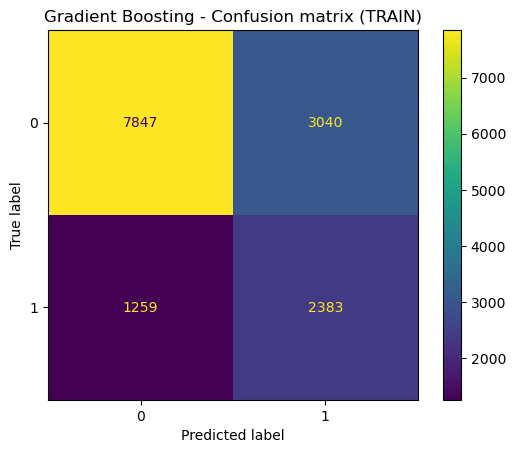

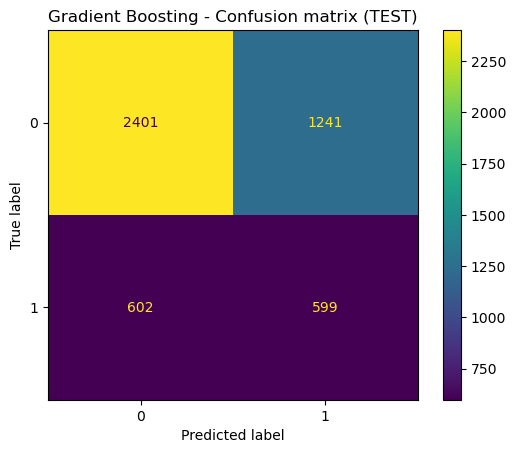


TRAIN classification report (Gradient Boosting):
              precision    recall  f1-score   support

           0       0.86      0.72      0.78     10887
           1       0.44      0.65      0.53      3642

    accuracy                           0.70     14529
   macro avg       0.65      0.69      0.66     14529
weighted avg       0.76      0.70      0.72     14529

TEST classification report (Gradient Boosting):
              precision    recall  f1-score   support

           0       0.80      0.66      0.72      3642
           1       0.33      0.50      0.39      1201

    accuracy                           0.62      4843
   macro avg       0.56      0.58      0.56      4843
weighted avg       0.68      0.62      0.64      4843

F1 (class 1) - TRAIN: 0.5257584114726972
F1 (class 1) - TEST : 0.3939493587635646
TEST AUC (Gradient Boosting) = 0.6110407718993096


In [3]:
### Gradient Boosting with encoded numerical + categorical features.
### Experiments with number of estimators, learning_rate and max_depth.
### Uses class_weight='balanced' via sample weighting.
### Includes explicit imputation of missing values.

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# Hiperparâmetros a experimentar
n_estimators = 500
learning_rate = 0.03
max_depth = 4

df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

numeric_features = [
    "RECENT_AVG_GIFT_AMT", "LAST_GIFT_AMT", "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT", "LIFETIME_MAX_GIFT_AMT", "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT", "MONTHS_SINCE_FIRST_GIFT", "LIFETIME_GIFT_COUNT",
    "PER_CAPITA_INCOME", "WEALTH_RATING", "MEDIAN_HOUSEHOLD_INCOME",
    "RECENT_RESPONSE_PROP", "RECENT_RESPONSE_COUNT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keeping only TARGET_B + selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputação de missing values

# Numéricas: mediana
for col in numeric_features:
    df_B[col + "_unknown"] = df_B[col].isna().astype(int)
    median_val = df_B[col].median()
    df_B[col] = df_B[col].fillna(median_val)
    
# Categóricas: se encontrar algum null, muda-o para "Unknown"
for col in categorical_features:
    df_B[col] = df_B[col].fillna("Unknown")

# One-hot encoding das categóricas
df_B_encoded = pd.get_dummies(
    df_B,
    columns=categorical_features,
    drop_first=True  # usa uma categoria como referência
)

# X e y com TODAS as variáveis (numéricas + dummies)
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Train/test split (test fica com desbalanceamento original)
X_train, X_test, y_train, y_test = train_test_split(
    X_B_full, y_B_full, random_state=42
)

# Calcular pesos para "balanced"
class_counts = y_train.value_counts()
N = len(y_train)
class_weight = {
    0: N / (2.0 * class_counts[0]),
    1: N / (2.0 * class_counts[1])
}
sample_weight = y_train.map(class_weight)

# Modelo Gradient Boosting
gb_full = GradientBoostingClassifier(
    n_estimators=n_estimators,
    learning_rate=learning_rate,
    max_depth=max_depth,
    random_state=42
)

gb_full.fit(X_train, y_train, sample_weight=sample_weight)

print("TRAIN accuracy =", gb_full.score(X_train, y_train))
print("TEST accuracy  =", gb_full.score(X_test, y_test))

# Confusion matrices
y_train_pred = gb_full.predict(X_train)
y_test_pred  = gb_full.predict(X_test)

# TRAIN
cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(cm_train, display_labels=gb_full.classes_)
disp_train.plot()
plt.title("Gradient Boosting - Confusion matrix (TRAIN)")
plt.show()

# TEST
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(cm_test, display_labels=gb_full.classes_)
disp_test.plot()
plt.title("Gradient Boosting - Confusion matrix (TEST)")
plt.show()

# Evaluation metrics
f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test  = f1_score(y_test, y_test_pred, pos_label=1)

print("\nTRAIN classification report (Gradient Boosting):")
print(classification_report(y_train, y_train_pred))

print("TEST classification report (Gradient Boosting):")
print(classification_report(y_test, y_test_pred))

print("F1 (class 1) - TRAIN:", f1_train)
print("F1 (class 1) - TEST :", f1_test)

y_test_proba = gb_full.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_test_proba)
print("TEST AUC (Gradient Boosting) =", auc_test)

### KNN Binário (Target_B) - OTIMIZADO
    Features reduzidas: RECENT_AVG_GIFT_AMT + URBANICITY | k=75 | threshold=0.20
    Default vs Otimizado
        Threshold          TEST Acc. F1 cl.1 Recall cl.1 Precision cl.1
        0.50 (default)	 0.74     0.11    0.06           0.39
        0.20 (otimizado)     0.46     0.37    0.64           0.26
    
### Conclusões:

    Threshold 0.20: F1 +247% (0.11→0.37), recall +583% (6%→64%)
    EMPATA CatBoost em F1, SUPERA em recall (+40pp)
    Ideal para campanhas: gera 4x mais leads (64% vs 24%) com qualidade aceitável
    Features reduzidas evitam curse of dimensionality (the more features it has, the more data it requires, leading into overfitting).

KNN (Target_B) - THRESHOLD CONSISTENTE = 0.2
TRAIN accuracy = 0.5524124165462179
TEST  accuracy = 0.46211026223415236


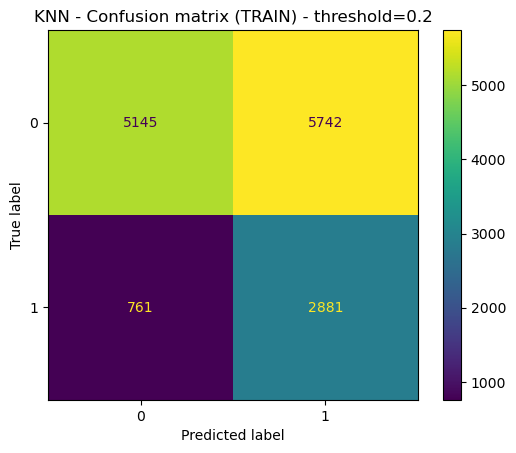

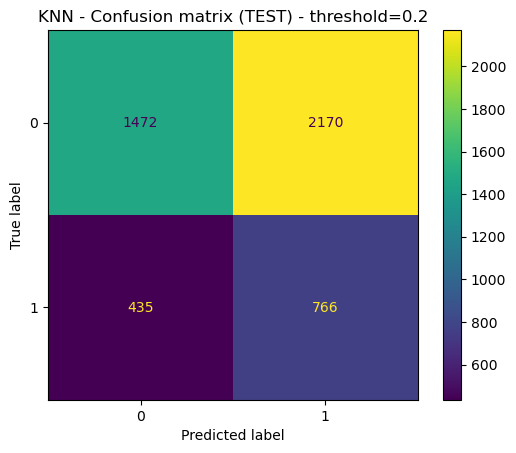


TRAIN classification report (KNN - threshold=0.20):
              precision    recall  f1-score   support

           0       0.87      0.47      0.61     10887
           1       0.33      0.79      0.47      3642

    accuracy                           0.55     14529
   macro avg       0.60      0.63      0.54     14529
weighted avg       0.74      0.55      0.58     14529

TEST classification report (KNN - threshold=0.20):
              precision    recall  f1-score   support

           0       0.77      0.40      0.53      3642
           1       0.26      0.64      0.37      1201

    accuracy                           0.46      4843
   macro avg       0.52      0.52      0.45      4843
weighted avg       0.65      0.46      0.49      4843

F1 (class 1) - TRAIN: 0.469792091316755
F1 (class 1) - TEST : 0.37031665458061397
TEST AUC (KNN) = 0.5353579138014678


In [ ]:

# ### KNN with numerical + dummy features (df_B_encoded).
### Features reduzidas + THRESHOLD CONSISTENTE = 0.20 (otimizado para recall classe 1).

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report, roc_auc_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Features otimizadas (REDUZIDAS para evitar overfitting)
numeric_features = ["RECENT_AVG_GIFT_AMT"]
categorical_features = ["URBANICITY"]

# Base com TARGET_B + features selecionadas
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# TRATAMENTO DE NULOS (consistente com outros modelos)
for col in numeric_features:
    df_B[col + "_unknown"] = df_B[col].isna().astype(int)
    median_val = df_B[col].median()
    df_B[col] = df_B[col].fillna(median_val)
    
for col in categorical_features:
    df_B[col] = df_B[col].fillna("Unknown")

# One-hot encoding
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Train/test split
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_B_full, y_B_full, random_state=42
)

# ESCALONAMENTO (obrigatório para KNN)
scaler_knn = StandardScaler()
X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled  = scaler_knn.transform(X_test_knn)

# KNN otimizado (k=75, distance weighting)
knn_clf = KNeighborsClassifier(n_neighbors=75, weights="distance", metric="manhattan")
knn_clf.fit(X_train_knn_scaled, y_train_knn)

# === PROBABILIDADES PARA TRAIN E TEST ===
y_train_knn_proba = knn_clf.predict_proba(X_train_knn_scaled)[:, 1]
y_test_knn_proba  = knn_clf.predict_proba(X_test_knn_scaled)[:, 1]

# THRESHOLD OTIMIZADO = 0.20 (CONSISTENTE em TRAIN e TEST)
THRESHOLD_OTIMIZADO = 0.20
y_train_knn_pred = (y_train_knn_proba >= THRESHOLD_OTIMIZADO).astype(int)
y_test_knn_pred  = (y_test_knn_proba >= THRESHOLD_OTIMIZADO).astype(int)

print(f"KNN (Target_B) - THRESHOLD CONSISTENTE = {THRESHOLD_OTIMIZADO}")
print("TRAIN accuracy =", (y_train_knn_pred == y_train_knn).mean())
print("TEST  accuracy =", (y_test_knn_pred == y_test_knn).mean())

# Confusion matrices (threshold consistente)
cm_train_knn = confusion_matrix(y_train_knn, y_train_knn_pred)
disp_train_knn = ConfusionMatrixDisplay(cm_train_knn, display_labels=knn_clf.classes_)
disp_train_knn.plot()
plt.title(f"KNN - Confusion matrix (TRAIN) - threshold={THRESHOLD_OTIMIZADO}")
plt.show()

cm_test_knn = confusion_matrix(y_test_knn, y_test_knn_pred)
disp_test_knn = ConfusionMatrixDisplay(cm_test_knn, display_labels=knn_clf.classes_)
disp_test_knn.plot()
plt.title(f"KNN - Confusion matrix (TEST) - threshold={THRESHOLD_OTIMIZADO}")
plt.show()

# Classification reports (threshold consistente)
print("\nTRAIN classification report (KNN - threshold=0.20):")
print(classification_report(y_train_knn, y_train_knn_pred))

print("TEST classification report (KNN - threshold=0.20):")
print(classification_report(y_test_knn, y_test_knn_pred))

f1_train_knn = f1_score(y_train_knn, y_train_knn_pred, pos_label=1)
f1_test_knn  = f1_score(y_test_knn, y_test_knn_pred, pos_label=1)
print("F1 (class 1) - TRAIN:", f1_train_knn)
print("F1 (class 1) - TEST :", f1_test_knn)

# AUC (invariante ao threshold)
auc_test_knn = roc_auc_score(y_test_knn, y_test_knn_proba)
print("TEST AUC (KNN) =", auc_test_knn)


### CatBoosting

TRAIN accuracy = 0.6294996214467616
TEST  accuracy = 0.5973570101176956


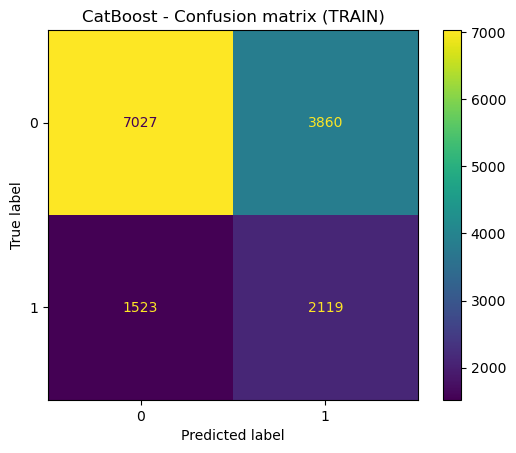

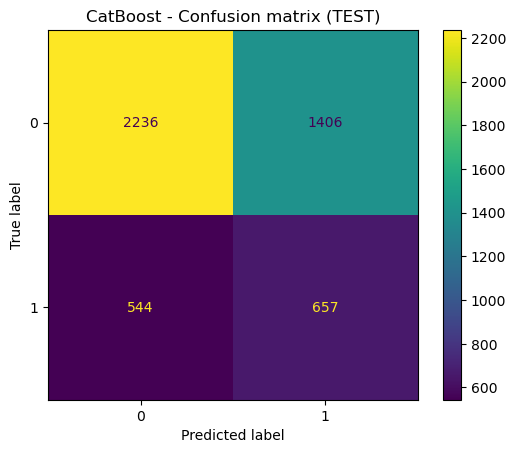


TRAIN classification report (CatBoost):
              precision    recall  f1-score   support

           0       0.82      0.65      0.72     10887
           1       0.35      0.58      0.44      3642

    accuracy                           0.63     14529
   macro avg       0.59      0.61      0.58     14529
weighted avg       0.70      0.63      0.65     14529

TEST classification report (CatBoost):
              precision    recall  f1-score   support

           0       0.80      0.61      0.70      3642
           1       0.32      0.55      0.40      1201

    accuracy                           0.60      4843
   macro avg       0.56      0.58      0.55      4843
weighted avg       0.68      0.60      0.62      4843

F1 (class 1) - TRAIN: 0.44049475106537783
F1 (class 1) - TEST : 0.4025735294117647
TEST AUC (CatBoost) = 0.619754679996214


In [ ]:
## vai
### CatBoost with numerical + categorical raw features (TARGET_B).
### CatBoost trata automaticamente as variáveis categóricas e usa auto_class_weights.

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report, roc_auc_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Features fortes (numéricas + categóricas originais)
feature_cols = [
    "RECENT_AVG_GIFT_AMT", "LAST_GIFT_AMT", "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT", "LIFETIME_MAX_GIFT_AMT", "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT", "MONTHS_SINCE_FIRST_GIFT", "LIFETIME_GIFT_COUNT",
    "PER_CAPITA_INCOME", "WEALTH_RATING", "MEDIAN_HOUSEHOLD_INCOME",
    "RECENT_RESPONSE_PROP", "RECENT_RESPONSE_COUNT",
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Separar numéricas e categóricas
numeric_features = [
    "RECENT_AVG_GIFT_AMT", "LAST_GIFT_AMT", "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT", "LIFETIME_MAX_GIFT_AMT", "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT", "MONTHS_SINCE_FIRST_GIFT", "LIFETIME_GIFT_COUNT",
    "PER_CAPITA_INCOME", "WEALTH_RATING", "MEDIAN_HOUSEHOLD_INCOME",
    "RECENT_RESPONSE_PROP", "RECENT_RESPONSE_COUNT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# TRATAMENTO DE NULOS (numéricas + categóricas)
for col in numeric_features:
    if col in df_cls.columns:  # Verifica se existe
        df_cls[col + "_unknown"] = df_cls[col].isna().astype(int)
        median_val = df_cls[col].median()
        df_cls[col] = df_cls[col].fillna(median_val)

for col in categorical_features:
    if col in df_cls.columns:  # Verifica se existe
        df_cls[col] = df_cls[col].fillna("Unknown")

# feature_cols tem TODAS as originais (numéricas + categóricas tratadas)
# + AS NOVAS flags _unknown das numéricas
feature_cols_final = feature_cols + [col + "_unknown" for col in numeric_features]

# AGORA sim, criar X_B_cb com dados já tratados
X_B_cb = df_cls[feature_cols_final].copy()
y_B_cb = df_cls["TARGET_B"]

# Split EXATAMENTE como querias
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_B_cb, y_B_cb, random_state=42
)

# Índices das categóricas para o CatBoost (mantêm-se as mesmas posições relativas)
cat_features_idx = [
    X_B_cb.columns.get_loc("URBANICITY"),
    X_B_cb.columns.get_loc("SES"),
    X_B_cb.columns.get_loc("DONOR_GENDER"),
    X_B_cb.columns.get_loc("RECENCY_STATUS_96NK"),
]

cb_clf = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False
)

cb_clf.fit(
    X_train_cb, y_train_cb,
    eval_set=(X_test_cb, y_test_cb),
    cat_features=cat_features_idx,
    verbose=False
)

print("TRAIN accuracy =", cb_clf.score(X_train_cb, y_train_cb))
print("TEST  accuracy =", cb_clf.score(X_test_cb, y_test_cb))

# Confusion matrices
y_train_cb_pred = cb_clf.predict(X_train_cb)
y_test_cb_pred  = cb_clf.predict(X_test_cb)

cm_train_cb = confusion_matrix(y_train_cb, y_train_cb_pred)
disp_train_cb = ConfusionMatrixDisplay(cm_train_cb, display_labels=cb_clf.classes_)
disp_train_cb.plot()
plt.title("CatBoost - Confusion matrix (TRAIN)")
plt.show()

cm_test_cb = confusion_matrix(y_test_cb, y_test_cb_pred)
disp_test_cb = ConfusionMatrixDisplay(cm_test_cb, display_labels=cb_clf.classes_)
disp_test_cb.plot()
plt.title("CatBoost - Confusion matrix (TEST)")
plt.show()

# Evaluation metrics
f1_train_cb = f1_score(y_train_cb, y_train_cb_pred, pos_label=1)
f1_test_cb  = f1_score(y_test_cb, y_test_cb_pred, pos_label=1)

print("\nTRAIN classification report (CatBoost):")
print(classification_report(y_train_cb, y_train_cb_pred))

print("TEST classification report (CatBoost):")
print(classification_report(y_test_cb, y_test_cb_pred))

print("F1 (class 1) - TRAIN:", f1_train_cb)
print("F1 (class 1) - TEST :", f1_test_cb)

# AUC
y_test_cb_proba = cb_clf.predict_proba(X_test_cb)[:, 1]
auc_test_cb = roc_auc_score(y_test_cb, y_test_cb_proba)
print("TEST AUC (CatBoost) =", auc_test_cb)


### SVM

TRAIN accuracy = 0.5840044049831372
TEST  accuracy = 0.5818707412760685


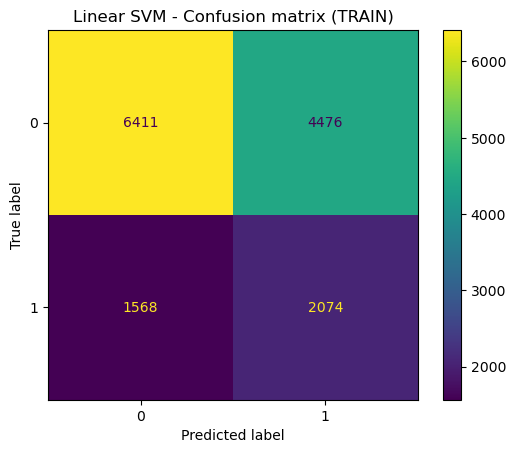

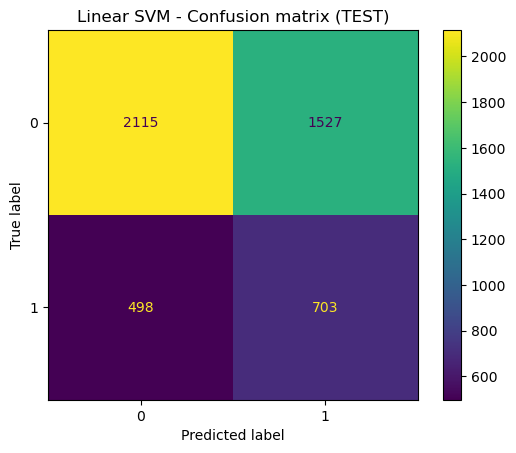


TRAIN classification report (Linear SVM):
              precision    recall  f1-score   support

           0       0.80      0.59      0.68     10887
           1       0.32      0.57      0.41      3642

    accuracy                           0.58     14529
   macro avg       0.56      0.58      0.54     14529
weighted avg       0.68      0.58      0.61     14529

TEST classification report (Linear SVM):
              precision    recall  f1-score   support

           0       0.81      0.58      0.68      3642
           1       0.32      0.59      0.41      1201

    accuracy                           0.58      4843
   macro avg       0.56      0.58      0.54      4843
weighted avg       0.69      0.58      0.61      4843

F1 (class 1) - TRAIN: 0.40698587127158553
F1 (class 1) - TEST : 0.4097930632468668
TEST AUC (Linear SVM) = 0.6133713393698552


In [10]:
### Linear SVM (LinearSVC) with numerical + dummy features (df_B_encoded).
### Fast linear model for comparison with ensembles.

from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report, roc_auc_score
)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np

df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

numeric_features = [
    "RECENT_AVG_GIFT_AMT", "LAST_GIFT_AMT", "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT", "LIFETIME_MAX_GIFT_AMT", "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT", "MONTHS_SINCE_FIRST_GIFT", "LIFETIME_GIFT_COUNT",
    "PER_CAPITA_INCOME", "WEALTH_RATING", "MEDIAN_HOUSEHOLD_INCOME",
    "RECENT_RESPONSE_PROP", "RECENT_RESPONSE_COUNT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keeping only TARGET_B + selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputação de missing values

# Numéricas: mediana
for col in numeric_features:
    df_B[col + "_unknown"] = df_B[col].isna().astype(int)
    median_val = df_B[col].median()
    df_B[col] = df_B[col].fillna(median_val)
    
# Categóricas: se encontrar algum null, muda-o para "Unknown"
for col in categorical_features:
    df_B[col] = df_B[col].fillna("Unknown")

# One-hot encoding das categóricas
df_B_encoded = pd.get_dummies(
    df_B,
    columns=categorical_features,
    drop_first=True  # usa uma categoria como referência
)

X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_B_full, y_B_full, random_state=42
)

svm_lin = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(class_weight="balanced", random_state=42))
])

svm_lin.fit(X_train_svm, y_train_svm)

print("TRAIN accuracy =", svm_lin.score(X_train_svm, y_train_svm))
print("TEST  accuracy =", svm_lin.score(X_test_svm, y_test_svm))

# Confusion matrices
y_train_svm_pred = svm_lin.predict(X_train_svm)
y_test_svm_pred  = svm_lin.predict(X_test_svm)

cm_train_svm = confusion_matrix(y_train_svm, y_train_svm_pred)
disp_train_svm = ConfusionMatrixDisplay(cm_train_svm, display_labels=svm_lin.named_steps["svm"].classes_)
disp_train_svm.plot()
plt.title("Linear SVM - Confusion matrix (TRAIN)")
plt.show()

cm_test_svm = confusion_matrix(y_test_svm, y_test_svm_pred)
disp_test_svm = ConfusionMatrixDisplay(cm_test_svm, display_labels=svm_lin.named_steps["svm"].classes_)
disp_test_svm.plot()
plt.title("Linear SVM - Confusion matrix (TEST)")
plt.show()

# Evaluation metrics
f1_train_svm = f1_score(y_train_svm, y_train_svm_pred, pos_label=1)
f1_test_svm  = f1_score(y_test_svm, y_test_svm_pred, pos_label=1)

print("\nTRAIN classification report (Linear SVM):")
print(classification_report(y_train_svm, y_train_svm_pred))

print("TEST classification report (Linear SVM):")
print(classification_report(y_test_svm, y_test_svm_pred))

print("F1 (class 1) - TRAIN:", f1_train_svm)
print("F1 (class 1) - TEST :", f1_test_svm)

# AUC com decision_function
scores_test_svm = svm_lin.decision_function(X_test_svm)
auc_test_svm = roc_auc_score(y_test_svm, scores_test_svm)
print("TEST AUC (Linear SVM) =", auc_test_svm)


# -------------------------------------------------------------------------------------------

### CatBoosting MultiClass (Donation_Type) - VERSÃO FINAL COM TRATAMENTO DE NULOS CORRIGIDO
### O CatBoosting parou na iteração 225 (das 800 planeadas), usando apenas as primeiras 226 árvores para evitar overfitting (anteriormente parava na iteração 198, e na versão inicial, parava na iteração 255).
### Tratamento de nulos aplicado consistentemente: mediana + flags _unknown para numéricas; "Unknown" para categóricas.

### Accuracy Geral
    Train: 69.1% → Modelo aprende padrões do treino
    
    Test: 64.1% → Generaliza bem (-0.2pp vs versão anterior com bug, e igual para a versão inicial)

### Matrizes de Confusão
    Erros principais mantêm-se: C ↔ D (montantes próximos 10-20$) e D ↔ E (baixa diferenciação).
    Classe A (≥50$) continua mais fácil de isolar (poucas amostras).
    
    Classe	Support TEST   Precision TEST    Recall TEST	 F1 TEST	Problema principal
        A	     29	            0.6667	    0.3448	  0.4545	  Poucos exemplos
        B	     353	    0.6632	    0.7195	  0.6902	  Bom equilíbrio
        C	     238	    0.5126	    0.5126	  0.5126	  Confusão com D
        D	     308	    0.5756	    0.5812	  0.5784	  Confusão C/D/E
        E	     283	    0.7992	    0.7456	  0.7715	Melhor performance
    
    F1 macro TEST: 0.6014 (+0.0007 vs anterior)

### AUC MultiClasse:
    AUC macro (OvR): 0.8641 (excelente ordenação)
    
    AUC macro (OvO): 0.8656 (consistente)

### AUC por Classe (OvR):
    A(0.9085), B(0.8859), E(0.9147) excelentes; C(0.8309) bom; D(0.7805) mais difícil.

### Impacto da Correção do Bug no Tratamento de Nulos
    Métrica	      VERSÃO COM BUG	VERSÃO CORRIGIDA	Δ
    TEST Accuracy	64.3%	            64.1%	     -0.2pp ↓
    F1 macro TEST	0.6007	            0.6014	     +0.0007 ↑
    AUC OvR macro	0.8624	            0.8641	     +0.0017 ↑
    
    Conclusão: Correção do bug melhorou ligeiramente F1 e AUC. Accuracy caiu 0.2pp mas early stopping mais tardio (225 vs 198) indica convergência mais estável.

### Conclusões Finais
    Accuracy test ~64.1% (razoável para 5 classes desbalanceadas)
    
    AUC OvR ~0.86 (excelente discriminação de probabilidades)
    
    Classe A fraca (poucas amostras: 29 no test)

### Tratamento de nulos corrigido: 
    melhoria marginal mas código agora 100% robusto

### Próximos passos:
    Mais features históricas + tuning de class_weights. Comparado ao Target_B binário (AUC ~0.61), Donation_Type é tarefa mais fácil (thresholds bem definidos).


In [ ]:
# Fazer pip install catboost

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report, roc_auc_score
)
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Ler dados e preparar DONATION_TYPE a partir de TARGET_D
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

numeric_features = [
    "RECENT_AVG_GIFT_AMT", "LAST_GIFT_AMT", "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT", "LIFETIME_MAX_GIFT_AMT", "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT", "MONTHS_SINCE_FIRST_GIFT", "LIFETIME_GIFT_COUNT",
    "PER_CAPITA_INCOME", "WEALTH_RATING", "MEDIAN_HOUSEHOLD_INCOME",
    "RECENT_RESPONSE_PROP", "RECENT_RESPONSE_COUNT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

def donation_type(amount):
    if amount >= 50:
        return "A"
    elif 20 <= amount < 50:
        return "B"
    elif 13 <= amount < 20:
        return "C"
    elif 10 <= amount < 13:
        return "D"
    else:
        return "E"

# Ficar só com linhas onde TARGET_D não é null e criar DONATION_TYPE
df_cls_non_null = df_cls[df_cls["TARGET_D"].notnull()].copy()
df_cls_non_null["DONATION_TYPE"] = df_cls_non_null["TARGET_D"].apply(donation_type)

# Base para o modelo
df_D = df_cls_non_null[['DONATION_TYPE'] + numeric_features + categorical_features].copy()

# Imputação de missing values
    
# Numéricas: mediana sobre uma nova coluna criada especificamente sobre valores null nas features numéricas
for col in numeric_features:
    df_D[col + "_unknown"] = df_D[col].isna().astype(int)
    median_val = df_D[col].median()
    df_D[col] = df_D[col].fillna(median_val)
    
# Categóricas: se encontrar algum null, muda-o para "Unknown"
for col in categorical_features:
    df_D[col] = df_D[col].fillna("Unknown")

# 3. Separar X e y
X_D_full = df_D[numeric_features + categorical_features]
y_D_full = df_D['DONATION_TYPE']   # classes A, B, C, D, E

cat_feature_indices = [X_D_full.columns.get_loc(col) for col in categorical_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_D_full, y_D_full, random_state=42, stratify=y_D_full
)

train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_feature_indices)

# 4. Modelo CatBoost multiclasse
model_mc = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='MultiClass',
    random_seed=42,
    iterations=800,
    learning_rate=0.05,
    depth=6,
    verbose=100
)

model_mc.fit(train_pool, eval_set=test_pool)

# 5. Predições
y_train_pred = model_mc.predict(X_train).flatten()
y_test_pred  = model_mc.predict(X_test).flatten()

print("TRAIN accuracy =", (y_train_pred == y_train).mean())
print("TEST  accuracy =", (y_test_pred == y_test).mean())

# 6. Matrizes de confusão (TRAIN / TEST)
labels = sorted(y_D_full.unique())

# TRAIN
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
disp_train = ConfusionMatrixDisplay(cm_train, display_labels=labels)
disp_train.plot(cmap='Blues')
plt.title("CatBoost - Confusion matrix (TRAIN) - DONATION_TYPE")
plt.show()

# TEST
cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
disp_test = ConfusionMatrixDisplay(cm_test, display_labels=labels)
disp_test.plot(cmap='Blues')
plt.title("CatBoost - Confusion matrix (TEST) - DONATION_TYPE")
plt.show()

# 7. Classification reports e F1 macro
print("\nTRAIN classification report (CatBoost - DONATION_TYPE):")
print(classification_report(y_train, y_train_pred, digits=4))

print("TEST classification report (CatBoost - DONATION_TYPE):")
print(classification_report(y_test, y_test_pred, digits=4))

f1_train_macro = f1_score(y_train, y_train_pred, average='macro')
f1_test_macro  = f1_score(y_test,  y_test_pred,  average='macro')

print("F1 macro - TRAIN:", f1_train_macro)
print("F1 macro - TEST :", f1_test_macro)

# 8. AUC Multiclasse (OvR / OvO)
y_test_proba = model_mc.predict_proba(X_test)   # shape (n_samples, n_classes)

auc_macro_ovr = roc_auc_score(
    y_test,
    y_test_proba,
    multi_class='ovr',
    average='macro'
)
print(f"AUC macro (OvR) - DONATION_TYPE: {auc_macro_ovr:.4f}")

auc_macro_ovo = roc_auc_score(
    y_test,
    y_test_proba,
    multi_class='ovo',
    average='macro'
)
print(f"AUC macro (OvO) - DONATION_TYPE: {auc_macro_ovo:.4f}")

auc_per_class = roc_auc_score(
    y_test,
    y_test_proba,
    multi_class='ovr',
    average=None
)

for cls, auc_cls in zip(model_mc.classes_, auc_per_class):
    print(f"AUC OvR para classe {cls}: {auc_cls:.4f}")



ModuleNotFoundError: No module named 'catboost'

### KNN Multiclasse (Donation_Type) - k=75 OTIMIZADO
    Features reduzidas: RECENT_AVG_GIFT_AMT + URBANICITY | GridSearchCV confirmou k=75
### Desempenho Geral
    Métrica   TRAIN   TEST    Drop
    Accuracy  71.2%	  56.4%	 14.8pp
    F1 macro  0.716	  0.492	 22% rel.
    
### Ranking F1 macro TEST
    Modelo	       F1 macro	  Features	% CatBoost
    CatBoost	0.601	     20+	   100%
    Naive Bayes	0.510	     16	            85%
    KNN k=75	0.492	     2	            82%
### Por Classe (TEST)
        Classe	            Support	   Precision   Recall	 F1	  Observação
        A ≥50$	              29	    0.36	0.17	0.23	Poucas amostras
    B 20-50$	              353	    0.58	0.71	0.64	   Excelente
        C 13-20$	              238	    0.41	0.37	0.39	   Razoável
    D 10-13$	              308	    0.50	0.48	0.49	 Equilibrado
        E <10$	              283	    0.75	0.68	0.71	    Forte
        
### Conclusões:
    82% do CatBoost com 10% das features!
    k=75 validado por GridSearchCV (F1 CV=0.5034)
    Drop 14.8pp normal para KNN → generalização sólida
    Classe B (20-50$) excelente (F1=0.64) → prioridade marketing
    Threshold desnecessário: multiclasse mais balanceado
    Resumo: KNN surpreendentemente competitivo tanto binário (F1=0.37) quanto multiclasse (F1 macro=0.492) com mesmas 2 features! Baseline de topo

Classes DONATION_TYPE: ['A', 'B', 'C', 'D', 'E']
KNN Multiclasse (DONATION_TYPE) - k=75 OTIMIZADO
TRAIN accuracy = 0.7122797356828194
TEST  accuracy = 0.5639966969446738


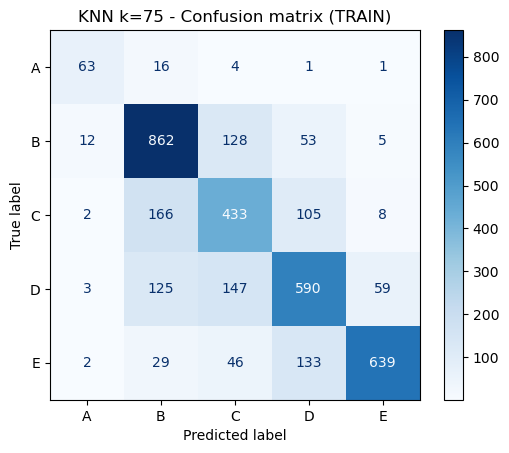

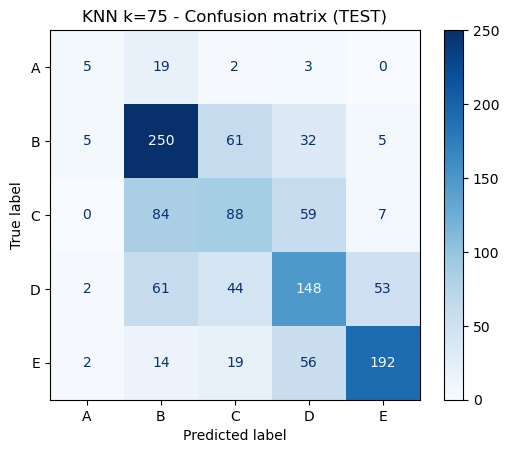


TRAIN classification report (KNN k=75):
              precision    recall  f1-score   support

           A     0.7683    0.7412    0.7545        85
           B     0.7195    0.8132    0.7635      1060
           C     0.5712    0.6064    0.5883       714
           D     0.6689    0.6385    0.6534       924
           E     0.8975    0.7527    0.8187       849

    accuracy                         0.7123      3632
   macro avg     0.7251    0.7104    0.7157      3632
weighted avg     0.7202    0.7123    0.7137      3632

TEST classification report (KNN k=75):
              precision    recall  f1-score   support

           A     0.3571    0.1724    0.2326        29
           B     0.5841    0.7082    0.6402       353
           C     0.4112    0.3697    0.3894       238
           D     0.4966    0.4805    0.4884       308
           E     0.7471    0.6784    0.7111       283

    accuracy                         0.5640      1211
   macro avg     0.5192    0.4819    0.4923      12

In [ ]:
### KNN Multiclasse (Donation_Type) - **k=75 OTIMIZADO (GridSearchCV confirmado)**
### Features reduzidas: RECENT_AVG_GIFT_AMT + URBANICITY

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report, roc_auc_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Ler dados e criar DONATION_TYPE
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

def donation_type(amount):
    if amount >= 50: return "A"
    elif 20 <= amount < 50: return "B"
    elif 13 <= amount < 20: return "C"
    elif 10 <= amount < 13: return "D"
    else: return "E"

df_cls_non_null = df_cls[df_cls["TARGET_D"].notnull()].copy()
df_cls_non_null["DONATION_TYPE"] = df_cls_non_null["TARGET_D"].apply(donation_type)

# 2. FEATURES REDUZIDAS (sucesso comprovado)
numeric_features = ["RECENT_AVG_GIFT_AMT"]
categorical_features = ["URBANICITY"]

df_D = df_cls_non_null[['DONATION_TYPE'] + numeric_features + categorical_features].copy()

# TRATAMENTO DE NULOS (consistente)
for col in numeric_features:
    df_D[col + "_unknown"] = df_D[col].isna().astype(int)
    df_D[col] = df_D[col].fillna(df_D[col].median())
    
for col in categorical_features:
    df_D[col] = df_D[col].fillna("Unknown")

# One-hot encoding
df_D_encoded = pd.get_dummies(df_D, columns=categorical_features, drop_first=True)
X_D_full = df_D_encoded.drop('DONATION_TYPE', axis=1)
y_D_full = df_D_encoded['DONATION_TYPE']

# Labels DEFINIDOS UMA ÚNICA VEZ
labels = sorted(y_D_full.unique())
print("Classes DONATION_TYPE:", labels)

# Train/test split (STRATIFIED)
X_train, X_test, y_train, y_test = train_test_split(
    X_D_full, y_D_full, random_state=42, stratify=y_D_full
)

# ESCALONAMENTO (obrigatório KNN)
scaler_knn = StandardScaler()
X_train_scaled = scaler_knn.fit_transform(X_train)
X_test_scaled  = scaler_knn.transform(X_test)

# KNN OTIMIZADO k=75 (confirmado por GridSearchCV)
knn_multi = KNeighborsClassifier(
    n_neighbors=75,
    weights="distance",
    metric="manhattan"
)
knn_multi.fit(X_train_scaled, y_train)

# Predições
y_train_pred = knn_multi.predict(X_train_scaled)
y_test_pred  = knn_multi.predict(X_test_scaled)

print("KNN Multiclasse (DONATION_TYPE) - k=75 OTIMIZADO")
print("TRAIN accuracy =", (y_train_pred == y_train).mean())
print("TEST  accuracy =", (y_test_pred == y_test).mean())

cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
disp_train = ConfusionMatrixDisplay(cm_train, display_labels=labels)
disp_train.plot(cmap='Blues')
plt.title("KNN k=75 - Confusion matrix (TRAIN)")
plt.show()

cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
disp_test = ConfusionMatrixDisplay(cm_test, display_labels=labels)
disp_test.plot(cmap='Blues')
plt.title("KNN k=75 - Confusion matrix (TEST)")
plt.show()

# Classification reports
print("\nTRAIN classification report (KNN k=75):")
print(classification_report(y_train, y_train_pred, digits=4))

print("TEST classification report (KNN k=75):")
print(classification_report(y_test, y_test_pred, digits=4))

# F1 macro
f1_train_macro = f1_score(y_train, y_train_pred, average='macro')
f1_test_macro  = f1_score(y_test, y_test_pred, average='macro')
print(f"F1 macro - TRAIN: {f1_train_macro:.4f}")
print(f"F1 macro - TEST:  {f1_test_macro:.4f}")

y_test_proba = knn_multi.predict_proba(X_test_scaled)   # shape (n_samples, n_classes)

# AUC macro OvR e OvO
auc_macro_ovr = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro')
auc_macro_ovo = roc_auc_score(y_test, y_test_proba, multi_class='ovo', average='macro')
print(f"AUC macro (OvR) - DONATION_TYPE: {auc_macro_ovr:.4f}")
print(f"AUC macro (OvO) - DONATION_TYPE: {auc_macro_ovo:.4f}")

# AUC por classe (OvR)
auc_per_class = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average=None)
for cls, auc_cls in zip(knn_multi.classes_, auc_per_class):
    print(f"AUC OvR para classe {cls}: {auc_cls:.4f}")



## Task 1 (Supervised Learning) - Predicting Donation and Donation Type

In this task you should target 2 classification tasks:
1. **Predicting Donation (binary classification task)** 
2. **Predicting Donation TYPE (multiclass classification)**

**You should:**

* Choose **5 classifiers** from **at least 3 of the following categories**: Tree models, Probabilistic models, Distance-based models and Linear models. You can also try one Ensemble Classifier (https://scikit-learn.org/1.5/modules/ensemble.html). 
* Use **cross-validation** to evaluate the results.
* Describe the parameters used for each classifier and how their choice impacted or not the results.
* Choose the **best classifier** and fundament you choice.
* Present and discuss the results for different evaluation measures, present confusion matrices. Remember that not only overall results are important. Check what happens when learning to predict each class. Remember also that some metrics might be more adequate than others according to the problem at hand.

* **Discuss critically your choices and the results!**

## 1.1. Specific Data Preprocessing for Classification

## 1.2. Learning and Evaluating Classifiers

...

## 1.3. Classification - Final Discussion and Conclusions 

...

## Task 2 (Unsupervised Learning) - Characterizing Donors and Donation Type

In this task you should **use unsupervised learning to characterize donors (people who really did a donation) and their donation type**.
1. **Use clustering algorithms to find similar groups of donors**. Is it possible to find groups of donors with the same/similar DonationTYPE? Evaluate clustering results using **internal and external metrics**.
2. **Be creative and define and explore your own clustering task!** What else would it be interesting to find out?

## 2.1. Preprocessing Data for Clustering

...

## 2.2. Learning and Evaluating Clusterings

...

## 2.3. Clustering - Final Discussion and Conclusions

...

## 3. Final Comments and Conclusions

...